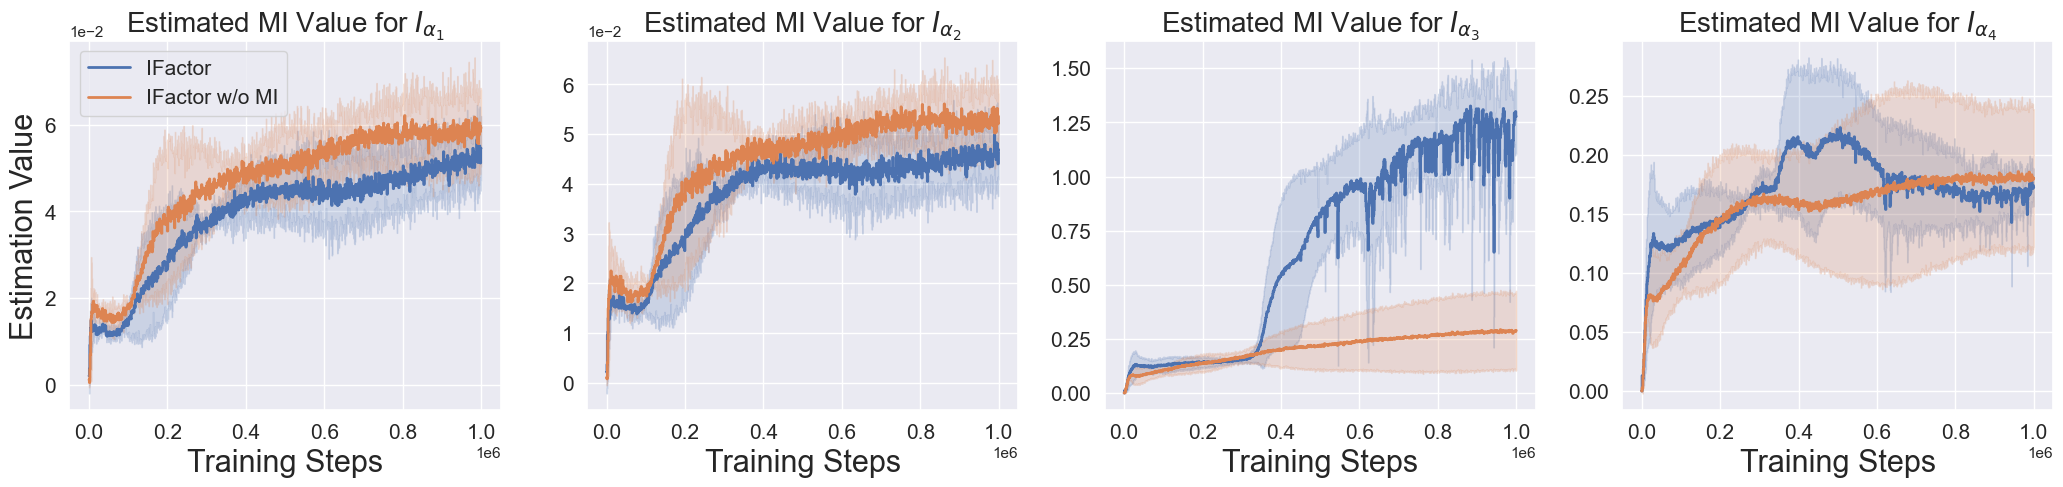

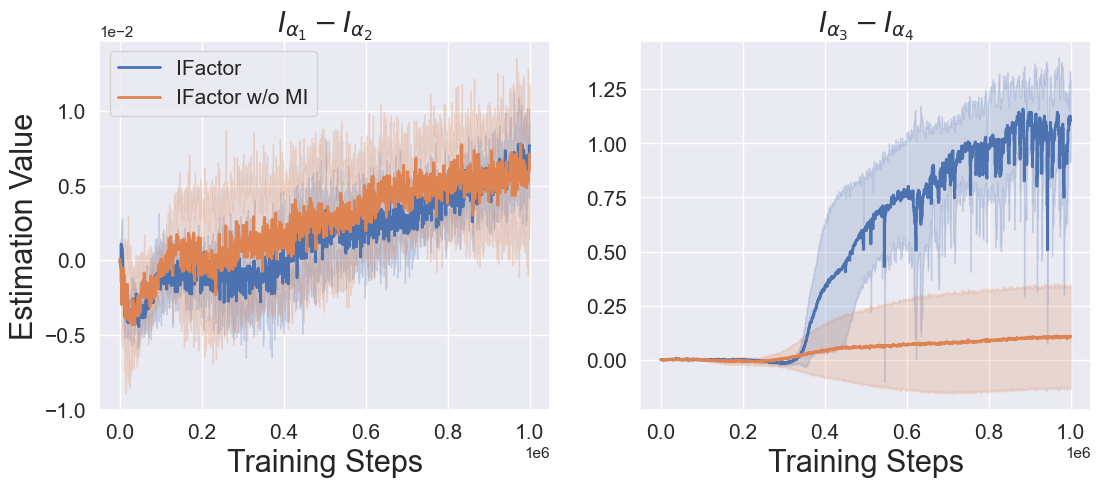

In [27]:
# Robodesk
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='darkgrid')
colors = sns.color_palette()
def plot_csv_files(ax, directory_path, title, interval=5, set_title=True, set_xlabel=True, set_ylabel=True, set_ysci=True, set_legend=False):
    files = os.listdir(directory_path)
    fig_width = 6.4
    fig_height = 4.8
    scale = 1.3
    method_data = []
    all_data = []
    column_name = ['x', 'y1', 'y2', 'y3']
    for file in files:
        if file.startswith('without'):
            file_path = os.path.join(directory_path, file)
            datawo = pd.read_csv(file_path, names=column_name)
            # print(data['x'][-1])
            mean = - datawo[column_name[1:]].mean(axis=1)
            std = datawo[column_name[1:]].std(axis=1)
            ax.plot(datawo['x'], mean, label='IFactor w/o MI', linewidth=2, color=colors[1])
            ax.fill_between(datawo['x'], mean - std, mean + std, alpha=0.2, color=colors[1])
        else:
            file_path = os.path.join(directory_path, file)
            data = pd.read_csv(file_path, names=column_name)
            data['x'] = data['x']
            # if file_path.endswith('with_action1.csv'):
            #     print(data.tail(10))
            # print(data['x'][-1])
            mean = - data[column_name[1:]].mean(axis=1)
            std = data[column_name[1:]].std(axis=1)
            ax.plot(data['x'], mean, label='IFactor', linewidth=2, color=colors[0])
            ax.fill_between(data['x'], mean - std, mean + std, alpha=0.2, color=colors[0])
        
    ax.ticklabel_format(axis="x", style="sci", scilimits=(0,0))
    if set_ysci:
        ax.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
    ax.tick_params(axis='x', labelsize=15)
    ax.tick_params(axis='y', labelsize=15)
    if set_title:
        ax.set_title(title, fontsize=20)
    if set_xlabel:
        ax.set_xlabel('Training Steps', fontsize=22)
    if set_ylabel:
        ax.set_ylabel('Estimation Value', fontsize=22)
    if set_legend:
        ax.legend(loc='upper left', fontsize=15)
    return data, datawo
    
title_1 = r'Estimated MI Value for $I_{\alpha_1}$'
title_2 = r'Estimated MI Value for $I_{\alpha_2}$'
title_3 = r'Estimated MI Value for $I_{\alpha_3}$'
title_4 = r'Estimated MI Value for $I_{\alpha_4}$'
title_reward = r'$I_{\alpha_1} - I_{\alpha_2}$'
title_action = r'$I_{\alpha_3} - I_{\alpha_4}$'

fig,axes = plt.subplots(1,4, figsize=(25.6, 4.8),)
mine_action = 'anonymized_path'
mine_reward = 'anonymized_path'
mine1 = 'anonymized_path'
mine2 = 'anonymized_path'
mine3 = 'anonymized_path'
mine4 = 'anonymized_path'
data_reward1, data_reward1wo = plot_csv_files(axes[0], mine1, title_1, interval=5, set_title=True, set_xlabel=True, set_ylabel=True, set_legend=True)
data_reward2, data_reward2wo = plot_csv_files(axes[1], mine2, title_2, interval=5, set_title=True, set_xlabel=True, set_ylabel=False)
data_action1, data_action1wo = plot_csv_files(axes[2], mine3, title_3, interval=5, set_title=True, set_xlabel=True, set_ylabel=False)
data_action2, data_action2wo = plot_csv_files(axes[3], mine4, title_4, interval=5, set_title=True, set_xlabel=True, set_ylabel=False, set_ysci=False)
# print(data_action1.tail(10), print(data_action2.tail(10)))

plt.savefig('anonymized_path/reacher_mine.pdf', bbox_inches='tight')

def plot_2(data, datawo, ax, title, set_ylabel=True, set_legend=False):
    mean = - data[['y1', 'y2', 'y3']].mean(axis=1)
    std = data[['y1', 'y2', 'y3']].std(axis=1)
    ax.plot(data['x'], mean, linewidth=2, label='IFactor', color=colors[0])
    ax.fill_between(data['x'], mean - std, mean + std, alpha=0.2, color=colors[0])
    mean = - datawo[['y1', 'y2', 'y3']].mean(axis=1)
    std = datawo[['y1', 'y2', 'y3']].std(axis=1)
    ax.plot(datawo['x'], mean, linewidth=2, label='IFactor w/o MI', color=colors[1])
    ax.fill_between(datawo['x'], mean - std, mean + std, alpha=0.2, color=colors[1])
    
    ax.ticklabel_format(axis="x", style="sci", scilimits=(0,0))
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
    ax.tick_params(axis='x', labelsize=15)
    ax.tick_params(axis='y', labelsize=15)
    ax.set_title(title, fontsize=20)
    ax.set_xlabel('Training Steps', fontsize=22)
    if set_ylabel:
        ax.set_ylabel('Estimation Value', fontsize=22)
    if set_legend:
        ax.legend(loc='upper left', fontsize=15)

ig,axes = plt.subplots(1,2, figsize=(12.8, 4.8),)

data_reward1[['y1', 'y2', 'y3']] -= data_reward2[['y1', 'y2', 'y3']]
data_action1[['y1', 'y2', 'y3']] -= data_action2[['y1', 'y2', 'y3']]
data_reward1wo[['y1', 'y2', 'y3']] -= data_reward2wo[['y1', 'y2', 'y3']]
data_action1wo[['y1', 'y2', 'y3']] -= data_action2wo[['y1', 'y2', 'y3']]
plot_2(data_reward1, data_reward1wo, axes[0], title_reward, True, set_legend=True)
plot_2(data_action1, data_action1wo, axes[1], title_action, False)
plt.savefig('reacher_mine_difference.pdf', bbox_inches='tight')

